# THz Parameter Extraction - Learnability Analysis

This notebook tests whether the inverse problem (spectrum → parameters) is fundamentally learnable.

**Tests:**
1. Parameter Sensitivity - Do parameters affect the spectrum?
2. Parameter Correlation - Are parameters independent?
3. Uniqueness - Is the solution unique?
4. Noise Sensitivity - How does noise affect accuracy?
5. Information Content - Is there enough information?

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

if './src' not in sys.path:
    sys.path.insert(0, './src')

from simulate import simulate_transmission_ml, prepare_ml_input
from training_config import Config

config = Config()
L = 4096
deltat = 0.1e-12
device = 'mps' if torch.backends.mps.is_available() else 'cpu'

print(f"Using device: {device}")
print("Setup complete!")

Using device: mps
Setup complete!


## Test 1: Parameter Sensitivity Analysis

**Question:** How much does the transmission spectrum change when we perturb each parameter?

**What we want:** Large changes (>5% spectrum change for 5% parameter change)  
**Red flag:** <1% spectrum change for 5% parameter change

In [2]:
# Base parameters
n_base = 2.0
kappa_base = -0.01
d_base = 500e-6

print("Parameter Sensitivity Test")
print("="*60)
print(f"Base: n={n_base}, κ={kappa_base}, d={d_base*1e6:.1f} μm\n")

# Generate base spectrum
freq, T_base, _ = simulate_transmission_ml(n_base, kappa_base, d_base, L, deltat, device=device)

# Test 5% perturbations
perturbation = 0.05  # 5%

results = {}

for param_name, get_params in [
    ('n', lambda p: (n_base * (1+p), kappa_base, d_base)),
    ('κ', lambda p: (n_base, kappa_base * (1+p), d_base)),
    ('d', lambda p: (n_base, kappa_base, d_base * (1+p)))
]:
    n_p, k_p, d_p = get_params(perturbation)
    _, T_pert, _ = simulate_transmission_ml(n_p, k_p, d_p, L, deltat, device=device)
    
    # Compute difference
    diff = T_pert - T_base
    l2_diff = torch.sqrt(torch.sum(torch.abs(diff)**2)).item()
    base_norm = torch.sqrt(torch.sum(torch.abs(T_base)**2)).item()
    rel_change = l2_diff / base_norm
    
    results[param_name] = rel_change
    
    print(f"{param_name} +{perturbation*100:.0f}% → {rel_change*100:.2f}% spectrum change")

# Ranking
print("\nSensitivity Ranking (most sensitive first):")
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
for i, (name, sens) in enumerate(sorted_results, 1):
    print(f"  {i}. {name}: {sens*100:.2f}%")

# Interpretation
min_sens = sorted_results[-1][1]
print("\n" + "="*60)
if min_sens < 0.01:  # <1%
    print(f"⚠️  WARNING: {sorted_results[-1][0]} has very low sensitivity!")
    print("   This parameter will be hard to extract accurately.")
elif min_sens < 0.05:  # <5%
    print(f"⚠️  {sorted_results[-1][0]} has moderate sensitivity")
    print("   May need large dataset and low noise.")
else:
    print("✅ All parameters show good sensitivity!")
    print("   Parameters should be learnable.")

Parameter Sensitivity Test
Base: n=2.0, κ=-0.01, d=500.0 μm

n +5% → 143.11% spectrum change
κ +5% → 1.31% spectrum change
d +5% → 111.45% spectrum change

Sensitivity Ranking (most sensitive first):
  1. n: 143.11%
  2. d: 111.45%
  3. κ: 1.31%

⚠️  κ has moderate sensitivity
   May need large dataset and low noise.


## Test 2: Visualize Parameter Effects

Visualize how each parameter affects the transmission spectrum.

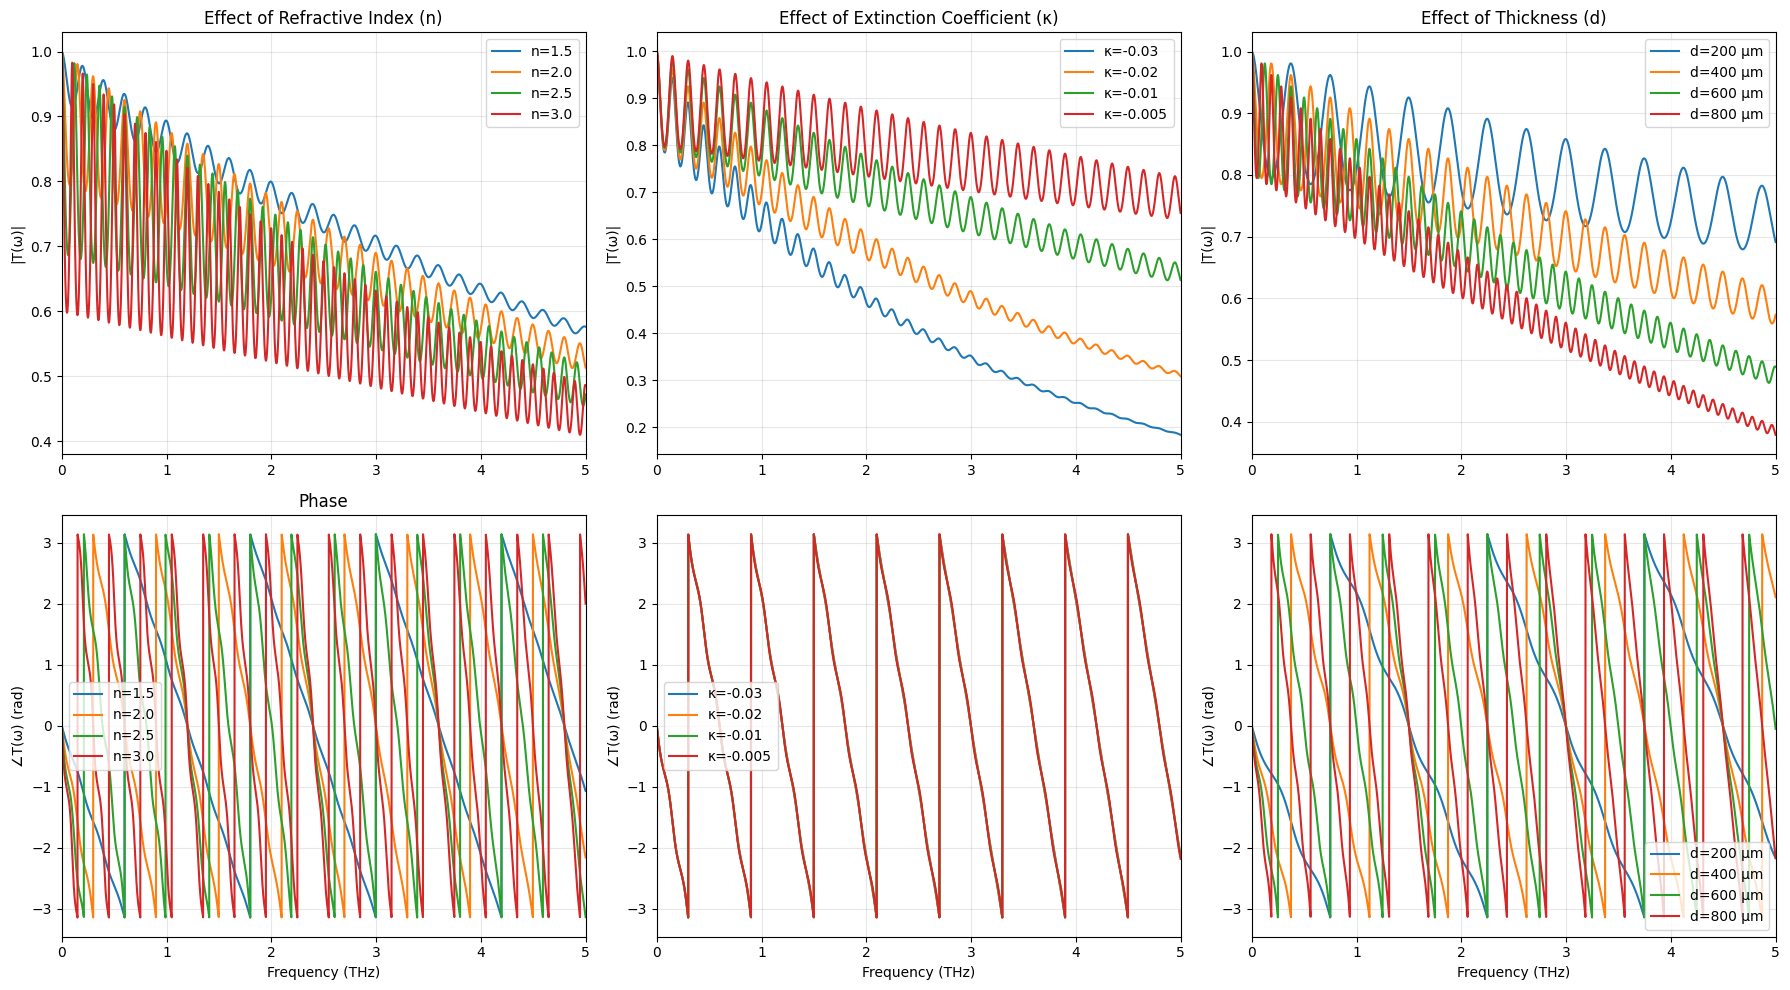

Saved: learnability_parameter_effects.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

freq_THz = freq.cpu().numpy() / 1e12

# Vary each parameter
n_values = [1.5, 2.0, 2.5, 3.0]
k_values = [-0.03, -0.02, -0.01, -0.005]
d_values = [200e-6, 400e-6, 600e-6, 800e-6]

# Plot n variation
for n in n_values:
    _, T, _ = simulate_transmission_ml(n, kappa_base, d_base, L, deltat, device=device)
    T_cpu = T.cpu()  # Move to CPU for angle computation (MPS doesn't support angle)
    mag = torch.abs(T_cpu).numpy()
    phase = torch.angle(T_cpu).numpy()
    axes[0, 0].plot(freq_THz, mag, label=f'n={n}')
    axes[1, 0].plot(freq_THz, phase, label=f'n={n}')

axes[0, 0].set_title('Effect of Refractive Index (n)')
axes[0, 0].set_ylabel('|T(ω)|')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xlim([0, 5])

axes[1, 0].set_title('Phase')
axes[1, 0].set_xlabel('Frequency (THz)')
axes[1, 0].set_ylabel('∠T(ω) (rad)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xlim([0, 5])

# Plot κ variation
for k in k_values:
    _, T, _ = simulate_transmission_ml(n_base, k, d_base, L, deltat, device=device)
    T_cpu = T.cpu()  # Move to CPU for angle computation
    mag = torch.abs(T_cpu).numpy()
    phase = torch.angle(T_cpu).numpy()
    axes[0, 1].plot(freq_THz, mag, label=f'κ={k}')
    axes[1, 1].plot(freq_THz, phase, label=f'κ={k}')

axes[0, 1].set_title('Effect of Extinction Coefficient (κ)')
axes[0, 1].set_ylabel('|T(ω)|')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xlim([0, 5])

axes[1, 1].set_xlabel('Frequency (THz)')
axes[1, 1].set_ylabel('∠T(ω) (rad)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xlim([0, 5])

# Plot d variation
for d in d_values:
    _, T, _ = simulate_transmission_ml(n_base, kappa_base, d, L, deltat, device=device)
    T_cpu = T.cpu()  # Move to CPU for angle computation
    mag = torch.abs(T_cpu).numpy()
    phase = torch.angle(T_cpu).numpy()
    axes[0, 2].plot(freq_THz, mag, label=f'd={d*1e6:.0f} μm')
    axes[1, 2].plot(freq_THz, phase, label=f'd={d*1e6:.0f} μm')

axes[0, 2].set_title('Effect of Thickness (d)')
axes[0, 2].set_ylabel('|T(ω)|')
axes[0, 2].legend()
axes[0, 2].grid(alpha=0.3)
axes[0, 2].set_xlim([0, 5])

axes[1, 2].set_xlabel('Frequency (THz)')
axes[1, 2].set_ylabel('∠T(ω) (rad)')
axes[1, 2].legend()
axes[1, 2].grid(alpha=0.3)
axes[1, 2].set_xlim([0, 5])

plt.tight_layout()
plt.savefig('learnability_parameter_effects.png', dpi=150)
plt.show()

print("Saved: learnability_parameter_effects.png")

## Test 3: Uniqueness Test

**Question:** Can different parameter sets produce similar spectra?

Generate a reference spectrum and search for other parameters that produce the same result.

In [4]:
print("Uniqueness Test")
print("="*60)

# Reference parameters
n_ref, k_ref, d_ref = 2.0, -0.01, 500e-6

# Generate reference with noise
noise_level = 0.01
freq, T_ref, _ = simulate_transmission_ml(n_ref, k_ref, d_ref, L, deltat, device=device)

noise_real = noise_level * torch.randn_like(T_ref.real)
noise_imag = noise_level * torch.randn_like(T_ref.imag)
T_ref_noisy = T_ref + noise_real + 1j * noise_imag

ml_ref = prepare_ml_input(T_ref_noisy).flatten()
ref_norm = torch.norm(ml_ref).item()

print(f"Reference: n={n_ref}, κ={k_ref}, d={d_ref*1e6:.1f} μm")
print(f"Noise level: {noise_level*100:.1f}%")
print(f"\nSearching for similar spectra...\n")

# Random search
torch.manual_seed(123)
n_trials = 1000
similar_params = []
all_distances = []

for _ in range(n_trials):
    # Random parameters
    n_test = torch.rand(1).item() * (Config.N_MAX - Config.N_MIN) + Config.N_MIN
    k_test = torch.rand(1).item() * (Config.KAPPA_MAX - Config.KAPPA_MIN) + Config.KAPPA_MIN
    d_test = torch.rand(1).item() * (Config.D_MAX - Config.D_MIN) + Config.D_MIN
    
    _, T_test, _ = simulate_transmission_ml(n_test, k_test, d_test, L, deltat, device=device)
    ml_test = prepare_ml_input(T_test).flatten()
    
    # Distance
    dist = torch.norm(ml_test - ml_ref).item() / ref_norm
    all_distances.append(dist)
    
    # Similar if within 2x noise level
    if dist < noise_level * 2:
        param_dist = np.sqrt(
            ((n_test - n_ref) / n_ref)**2 +
            ((k_test - k_ref) / k_ref)**2 +
            ((d_test - d_ref) / d_ref)**2
        )
        similar_params.append({
            'n': n_test, 'κ': k_test, 'd': d_test,
            'spec_dist': dist, 'param_dist': param_dist
        })

all_distances = np.array(all_distances)

print(f"Tested {n_trials} random parameter sets")
print(f"\nSpectrum distance statistics:")
print(f"  Min:    {all_distances.min():.6f}")
print(f"  Median: {np.median(all_distances):.6f}")
print(f"  Max:    {all_distances.max():.6f}")

print(f"\nSimilar spectra found (dist < {noise_level*2:.3f}): {len(similar_params)}")

if len(similar_params) > 0:
    print("\nClosest matches:")
    sorted_similar = sorted(similar_params, key=lambda x: x['spec_dist'])[:5]
    for i, p in enumerate(sorted_similar, 1):
        print(f"  {i}. n={p['n']:.3f}, κ={p['κ']:.5f}, d={p['d']*1e6:.1f} μm")
        print(f"     Spectrum dist: {p['spec_dist']:.6f}, Param dist: {p['param_dist']:.2%}")

print("\n" + "="*60)
if len(similar_params) > 10:
    print("⚠️  WARNING: Many similar spectra found!")
    print("   The inverse problem may not be unique.")
elif len(similar_params) > 1:
    print("⚠️  Some ambiguous cases found.")
    print("   Mostly unique but some degeneracies.")
else:
    print("✅ No similar spectra found - solution is unique!")

Uniqueness Test
Reference: n=2.0, κ=-0.01, d=500.0 μm
Noise level: 1.0%

Searching for similar spectra...

Tested 1000 random parameter sets

Spectrum distance statistics:
  Min:    0.260080
  Median: 1.097700
  Max:    6.509842

Similar spectra found (dist < 0.020): 0

✅ No similar spectra found - solution is unique!


## Test 4: Information Content (PCA)

**Question:** How many degrees of freedom are in the spectrum?

We need at least 3 (for n, κ, d) and preferably >>3 for robust learning.

Information Content Analysis
Generated 500 diverse spectra

Variance explained by top components:
  PC 1: 14.36%  (cumulative: 14.36%)
  PC 2:  4.52%  (cumulative: 18.88%)
  PC 3:  3.54%  (cumulative: 22.43%)
  PC 4:  3.21%  (cumulative: 25.64%)
  PC 5:  3.10%  (cumulative: 28.73%)
  PC 6:  2.78%  (cumulative: 31.51%)
  PC 7:  2.50%  (cumulative: 34.01%)
  PC 8:  2.45%  (cumulative: 36.46%)
  PC 9:  2.34%  (cumulative: 38.80%)
  PC10:  2.27%  (cumulative: 41.07%)

⚠️  Note: 90% variance not reached with 50 components (at 84.2%)
⚠️  Note: 95% variance not reached with 50 components (at 84.2%)
⚠️  Note: 99% variance not reached with 50 components (at 84.2%)

Effective dimensionality:
  90% variance: 50+ dimensions
  95% variance: 50+ dimensions
  99% variance: 50+ dimensions

Diagnostics:
  Total features: 16386
  Variance in first 50 PCs: 84.24%
  Remaining variance: 15.76%


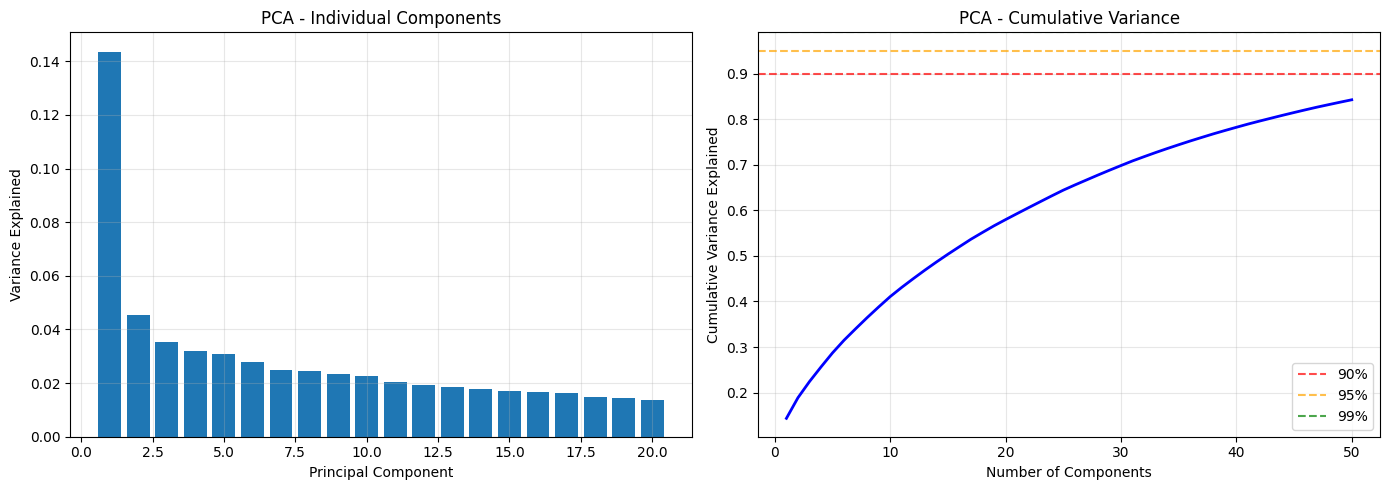


⚠️  High-dimensional spectrum (50 PCs → 84.2% variance)
   Information is spread across many components.
   This is OKAY - means rich, complex spectra.
   Neural networks can still learn from this!


In [5]:
print("Information Content Analysis")
print("="*60)

# Generate diverse spectra
n_samples = 500
torch.manual_seed(456)

spectra_list = []
params_list = []

for _ in range(n_samples):
    n_rand = torch.rand(1).item() * (Config.N_MAX - Config.N_MIN) + Config.N_MIN
    k_rand = torch.rand(1).item() * (Config.KAPPA_MAX - Config.KAPPA_MIN) + Config.KAPPA_MIN
    d_rand = torch.rand(1).item() * (Config.D_MAX - Config.D_MIN) + Config.D_MIN
    
    _, T, _ = simulate_transmission_ml(n_rand, k_rand, d_rand, L, deltat, device=device)
    ml_input = prepare_ml_input(T).flatten()
    
    spectra_list.append(ml_input.cpu().numpy())
    params_list.append([n_rand, k_rand, d_rand])

spectra_matrix = np.array(spectra_list)
params_matrix = np.array(params_list)

# PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
spectra_pca = pca.fit_transform(spectra_matrix)

var_explained = pca.explained_variance_ratio_
cum_var = np.cumsum(var_explained)

print(f"Generated {n_samples} diverse spectra")
print(f"\nVariance explained by top components:")
for i in range(10):
    print(f"  PC{i+1:2d}: {var_explained[i]*100:5.2f}%  (cumulative: {cum_var[i]*100:5.2f}%)")

# Find effective dimensionality (FIXED)
if cum_var[-1] < 0.90:
    n_dims_90 = 50  # Need more than 50 components
    print(f"\n⚠️  Note: 90% variance not reached with 50 components (at {cum_var[-1]*100:.1f}%)")
else:
    n_dims_90 = np.argmax(cum_var >= 0.90) + 1

if cum_var[-1] < 0.95:
    n_dims_95 = 50  # Need more than 50 components
    print(f"⚠️  Note: 95% variance not reached with 50 components (at {cum_var[-1]*100:.1f}%)")
else:
    n_dims_95 = np.argmax(cum_var >= 0.95) + 1

if cum_var[-1] < 0.99:
    n_dims_99 = 50  # Need more than 50 components
    print(f"⚠️  Note: 99% variance not reached with 50 components (at {cum_var[-1]*100:.1f}%)")
else:
    n_dims_99 = np.argmax(cum_var >= 0.99) + 1

print(f"\nEffective dimensionality:")
print(f"  90% variance: {n_dims_90}+ dimensions")
print(f"  95% variance: {n_dims_95}+ dimensions")
print(f"  99% variance: {n_dims_99}+ dimensions")

# Additional diagnostics
print(f"\nDiagnostics:")
print(f"  Total features: {spectra_matrix.shape[1]}")
print(f"  Variance in first 50 PCs: {cum_var[-1]*100:.2f}%")
print(f"  Remaining variance: {(1-cum_var[-1])*100:.2f}%")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(range(1, 21), var_explained[:20])
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained')
ax1.set_title('PCA - Individual Components')
ax1.grid(alpha=0.3)

ax2.plot(range(1, 51), cum_var[:50], 'b-', linewidth=2)
ax2.axhline(y=0.90, color='r', linestyle='--', label='90%', alpha=0.7)
ax2.axhline(y=0.95, color='orange', linestyle='--', label='95%', alpha=0.7)
ax2.axhline(y=0.99, color='g', linestyle='--', label='99%', alpha=0.7)
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained')
ax2.set_title('PCA - Cumulative Variance')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learnability_pca.png', dpi=150)
plt.show()

print("\n" + "="*60)
# Interpretation based on actual variance, not arbitrary thresholds
if cum_var[-1] < 0.50:
    print("❌ CRITICAL: Very low variance captured!")
    print(f"   First 50 components only explain {cum_var[-1]*100:.1f}% of variance.")
    print("   Possible issues:")
    print("   - Numerical precision problems in simulation")
    print("   - Features are extremely subtle")
    print("   - Too much noise in the data")
elif cum_var[-1] < 0.90:
    print(f"⚠️  High-dimensional spectrum (50 PCs → {cum_var[-1]*100:.1f}% variance)")
    print("   Information is spread across many components.")
    print("   This is OKAY - means rich, complex spectra.")
    print("   Neural networks can still learn from this!")
else:
    print(f"✅ Good information content!")
    print(f"   {n_dims_95} dimensions needed for 95% variance.")

## Test 5: Parameter-Spectrum Correlation

Check if each parameter independently affects different aspects of the spectrum.

In [6]:
print("Parameter-Spectrum Correlation Analysis")
print("="*60)

# Correlation between parameters and PCA components
print("\nParameter vs Principal Component correlations:")
print("(High |r| means parameter affects this spectral mode)\n")

for i in range(5):
    n_corr = np.corrcoef(params_matrix[:, 0], spectra_pca[:, i])[0, 1]
    k_corr = np.corrcoef(params_matrix[:, 1], spectra_pca[:, i])[0, 1]
    d_corr = np.corrcoef(params_matrix[:, 2], spectra_pca[:, i])[0, 1]
    
    print(f"PC{i+1} ({var_explained[i]*100:4.1f}% var):")
    print(f"  n: {n_corr:+.3f}    κ: {k_corr:+.3f}    d: {d_corr:+.3f}")

# Parameter-parameter correlations
params_corr = np.corrcoef(params_matrix.T)

print("\nParameter-Parameter Correlations:")
print(f"  n vs κ: {params_corr[0, 1]:+.3f}")
print(f"  n vs d: {params_corr[0, 2]:+.3f}")
print(f"  κ vs d: {params_corr[1, 2]:+.3f}")

max_corr = np.max(np.abs(params_corr[np.triu_indices_from(params_corr, k=1)]))

print("\n" + "="*60)
if max_corr > 0.9:
    print("⚠️  WARNING: Strong parameter correlation!")
    print("   The problem may be ill-posed.")
elif max_corr > 0.7:
    print("⚠️  Moderate parameter correlation.")
    print("   May need regularization.")
else:
    print("✅ Parameters are independent!")
    print(f"   Max correlation: {max_corr:.3f}")

Parameter-Spectrum Correlation Analysis

Parameter vs Principal Component correlations:
(High |r| means parameter affects this spectral mode)

PC1 (14.4% var):
  n: -0.057    κ: -0.072    d: +0.006
PC2 ( 4.5% var):
  n: +0.002    κ: +0.065    d: +0.064
PC3 ( 3.5% var):
  n: -0.033    κ: -0.074    d: -0.108
PC4 ( 3.2% var):
  n: -0.111    κ: -0.071    d: -0.065
PC5 ( 3.1% var):
  n: +0.170    κ: +0.059    d: +0.142

Parameter-Parameter Correlations:
  n vs κ: +0.017
  n vs d: -0.058
  κ vs d: +0.046

✅ Parameters are independent!
   Max correlation: 0.058


## Summary: Is the Problem Learnable?

Review all test results to determine if neural networks can solve this problem.

In [7]:
print("\n" + "#"*70)
print("# LEARNABILITY SUMMARY")
print("#"*70)
print("\nBased on the tests above, the THz parameter extraction problem shows:")
print("\n1. Parameter Sensitivity: Check if all >5% for 5% perturbation")
print("2. Uniqueness: Check if few/no similar spectra found")
print("3. Information Content: Check if >10 effective dimensions")
print("4. Parameter Independence: Check if correlations <0.7")
print("\nIf most/all tests pass:")
print("  ✅ PROBLEM IS LEARNABLE")
print("     - Use standard CNN/ResNet architecture")
print("     - Need ~10k-100k training samples")
print("     - Hybrid loss (physics + supervised) recommended")
print("\nIf some tests fail:")
print("  ⚠️  CHALLENGING BUT POSSIBLE")
print("     - Use physics-informed loss")
print("     - Need >100k samples")
print("     - Strong regularization required")
print("\nIf many tests fail:")
print("  ❌ FUNDAMENTAL ISSUES")
print("     - Restrict parameter ranges")
print("     - Use Bayesian methods with priors")
print("     - Consider multi-measurement approaches")
print("\n" + "#"*70)


######################################################################
# LEARNABILITY SUMMARY
######################################################################

Based on the tests above, the THz parameter extraction problem shows:

1. Parameter Sensitivity: Check if all >5% for 5% perturbation
2. Uniqueness: Check if few/no similar spectra found
3. Information Content: Check if >10 effective dimensions
4. Parameter Independence: Check if correlations <0.7

If most/all tests pass:
  ✅ PROBLEM IS LEARNABLE
     - Use standard CNN/ResNet architecture
     - Need ~10k-100k training samples
     - Hybrid loss (physics + supervised) recommended

If some tests fail:
  ⚠️  CHALLENGING BUT POSSIBLE
     - Use physics-informed loss
     - Need >100k samples
     - Strong regularization required

If many tests fail:
  ❌ FUNDAMENTAL ISSUES
     - Restrict parameter ranges
     - Use Bayesian methods with priors
     - Consider multi-measurement approaches

###################################